# XGBoost回归分析

## $\S1$ Configuration & Data Preparation

In [10]:
# Configuration
## Loading Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


## Data Path
Path = "./Raw_Data_3.xlsx"
Dependent_Variable = "USD_index_Close"

## Param Grid
param_grid = {
    "model__n_estimators": [50, 100, 200, 400],
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 1.0],                 # 行采样比例
    "model__colsample_bytree": [0.7, 1.0]           # 列采样比例
}

## CV Scoring
scoring = {
    ### sklearn默认maximize the score, so we use prefix "neg"
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}


In [11]:
# Data Preparation
## Loading Data
Data = pd.read_excel(Path, index_col="日期")
print("Data Size:", Data.shape)

## Data Split & Scale
### Split Features and Label
X = Data.drop(columns=[Dependent_Variable])
y = Data[[Dependent_Variable]]
# X,y = X.values, y.values

Data Size: (3420, 30)


In [12]:
### Split Train, Valid and Test Sets
train_size = int(len(Data) * 0.8)
X_train, X_test = X.iloc[:train_size, :], X.iloc[train_size:, :]
y_train, y_test = y.iloc[:train_size, :], y.iloc[train_size:, :]

#### Split Train Set into Tims Series
tsCV = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(tsCV.split(X_train)):
    print(f"Fold {fold}: Train {len(train_idx)}, Test {len(test_idx)}")


Fold 0: Train 456, Test 456
Fold 1: Train 912, Test 456
Fold 2: Train 1368, Test 456
Fold 3: Train 1824, Test 456
Fold 4: Train 2280, Test 456


## $\S2$ Model Training & Predicting

In [13]:
## Generating Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",
    )),
]
)

## Model Selection
### Grid_Search with Pipe on Grid using TimeSeriesSplit CV on Train Set
gsCV = GridSearchCV(
    estimator = pipe,
    param_grid=param_grid,
    cv = tsCV,
    scoring = scoring,
    refit = "R2",
    n_jobs = -1,
    verbose = 2
)
gsCV.fit(X_train, y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.7, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [50, 100, ...], ...}"
,scoring,"{'MAE': 'neg_mean_absolute_error', 'R2': 'r2', 'RMSE': 'neg_root_mean_squared_error'}"
,n_jobs,-1
,refit,'R2'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [14]:
### printing best model
#### Best Hyper Parameters:
print("Grid Search 最佳参数: ", gsCV.best_params_)
print("对应的(CV平均)最优R2:", gsCV.best_score_)

#### CV Results:
result = pd.DataFrame(gsCV.cv_results_)
cols_to_show = ["mean_test_RMSE", "mean_test_MAE", "mean_test_R2"]
result["mean_test_MAE"] = -result["mean_test_MAE"]
result["mean_test_RMSE"] = -result["mean_test_RMSE"]
print(result[cols_to_show].sort_values(by="mean_test_R2", ascending=False).head(10))

Grid Search 最佳参数:  {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 50, 'model__subsample': 0.7}
对应的(CV平均)最优R2: -0.9922329902648925
    mean_test_RMSE  mean_test_MAE  mean_test_R2
96        0.001826       0.001549     -0.992233
97        0.001831       0.001554     -1.011478
0         0.001827       0.001551     -1.014084
1         0.001829       0.001551     -1.021700
9         0.001846       0.001561     -1.059582
2         0.001807       0.001529     -1.061215
24        0.001851       0.001571     -1.070380
8         0.001851       0.001566     -1.086713
98        0.001815       0.001534     -1.089270
16        0.001855       0.001573     -1.094251


In [15]:
## Model Prediction
### 在gsCV中，refit已经选取了最优模型，Pipe在整个训练集上进行了重新训练
best_xgb = gsCV.best_estimator_
y_pred = best_xgb.predict(X_test)

Text(0.5, 1.0, 'XGBoost Regression Prediction')

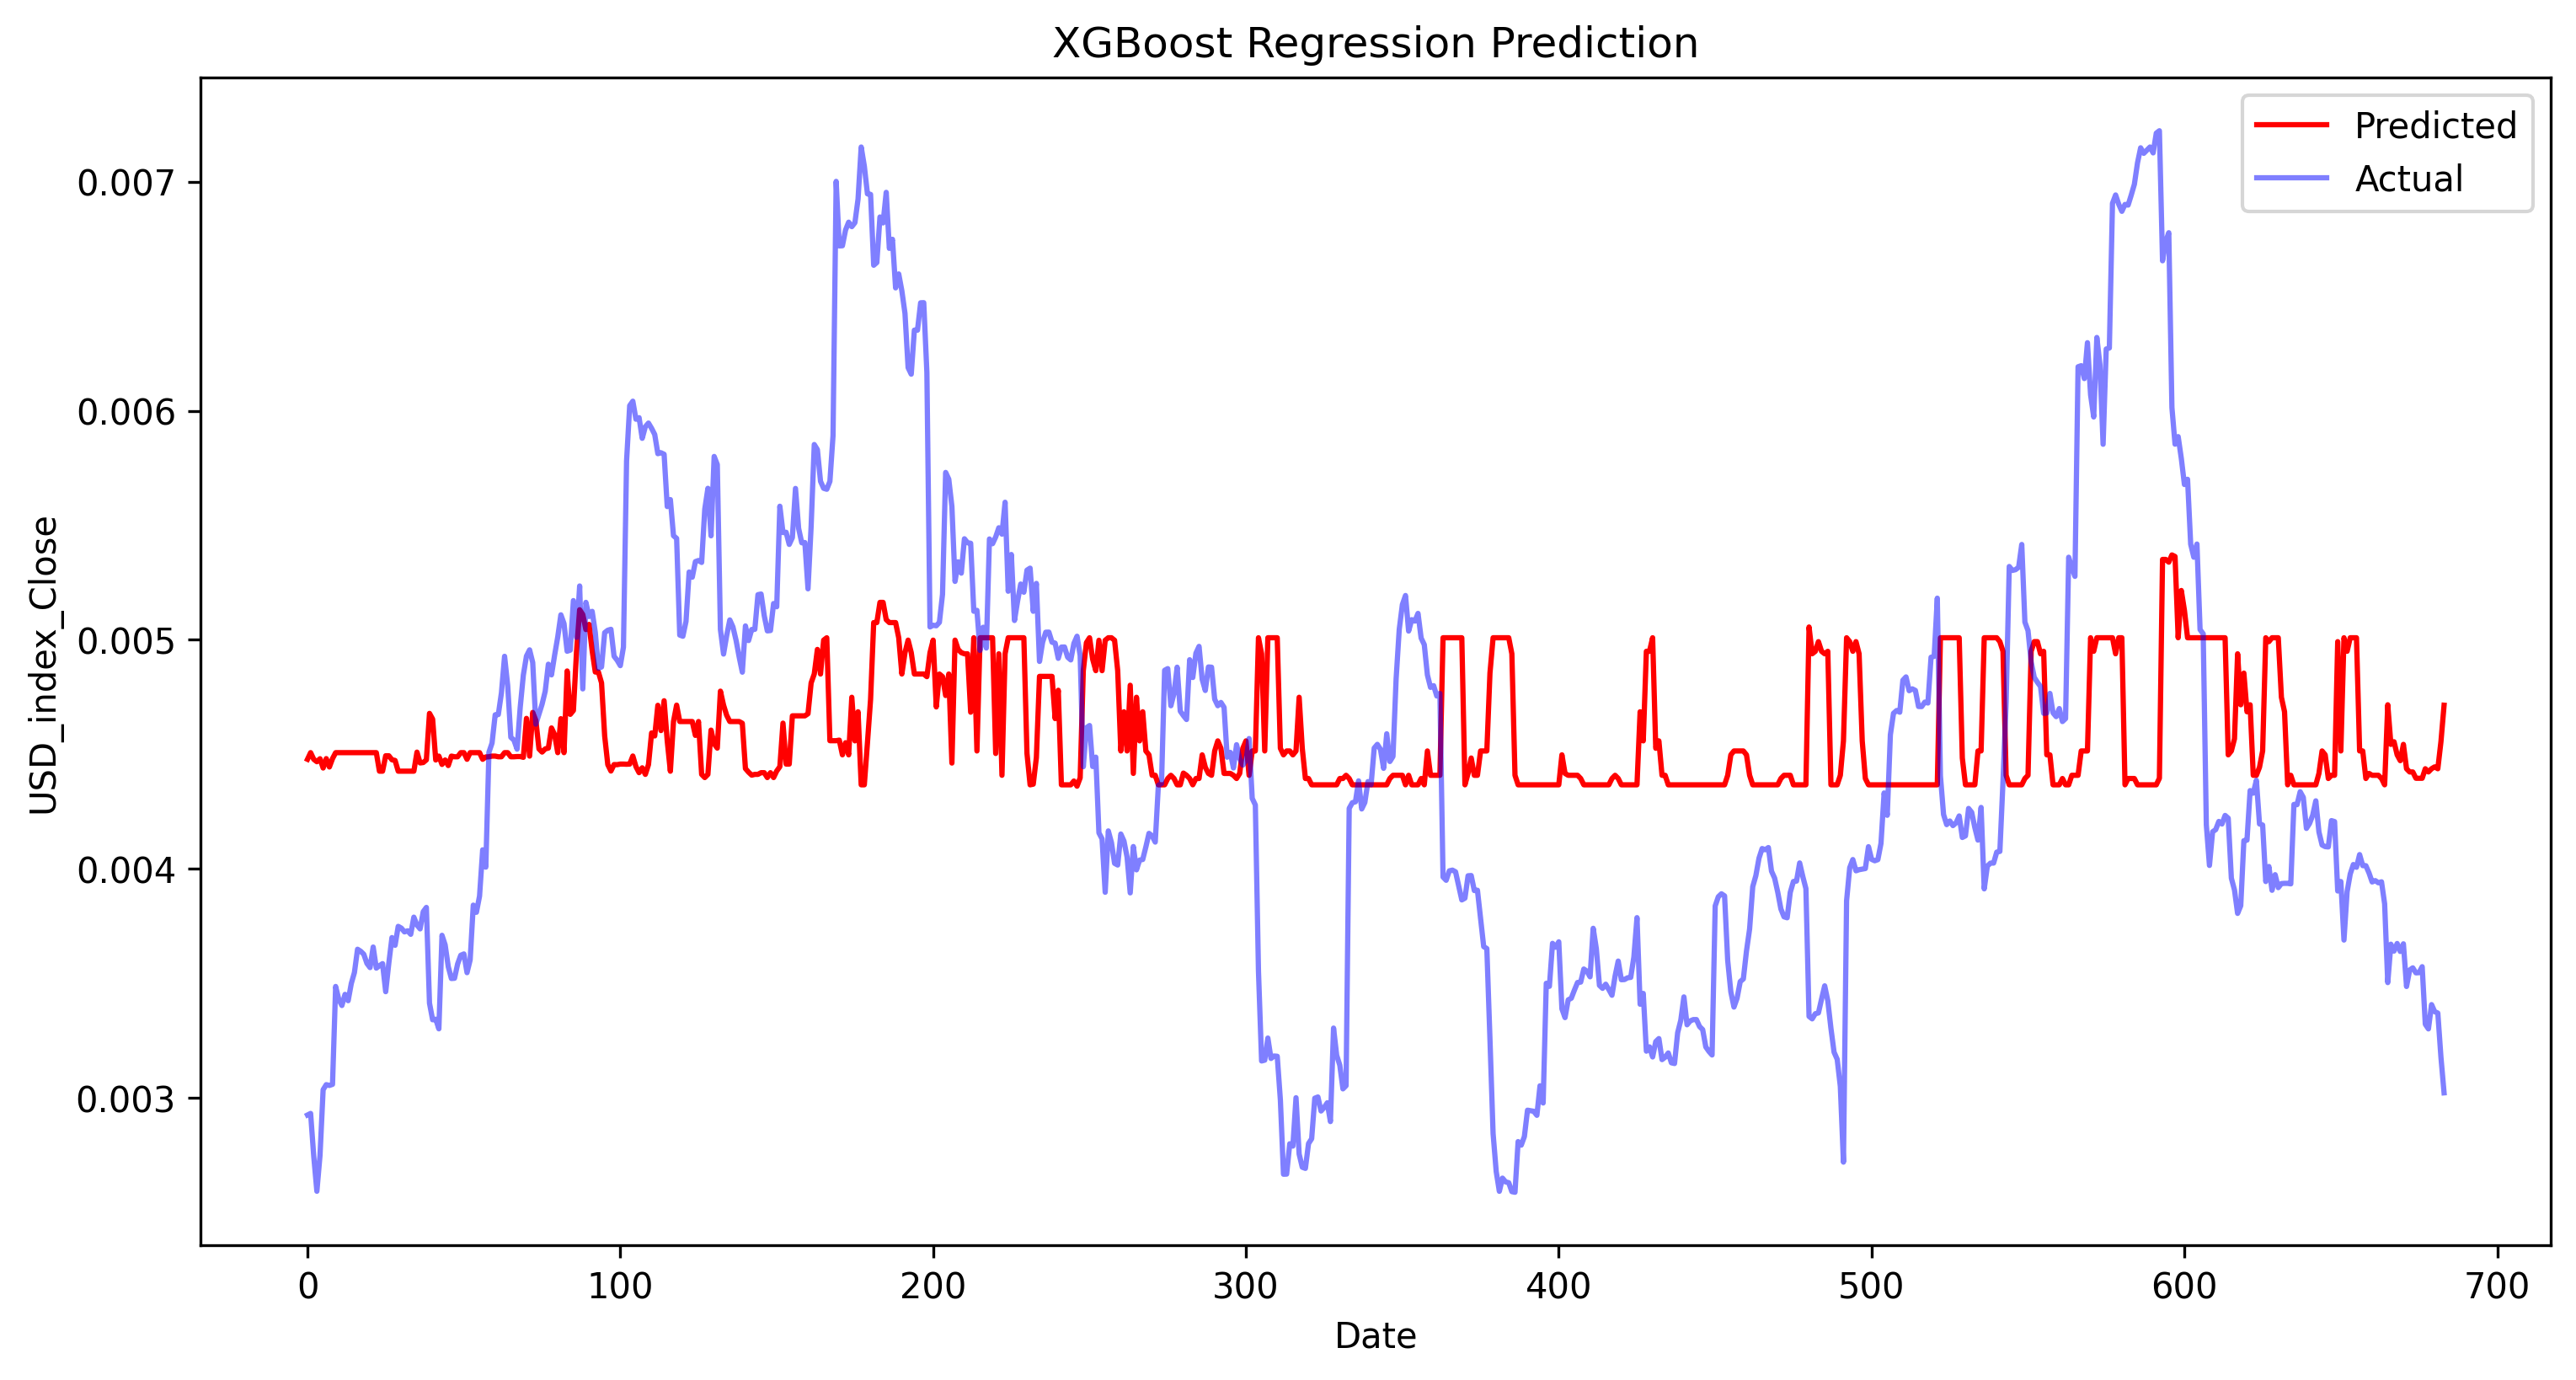

In [16]:
### Prediction Visualization
fig, ax1 = plt.subplots(figsize=(12,6), dpi=300)
ax1.plot(y_pred, label="Predicted", color="red")
ax1.plot(y_test.values, label="Actual", color="blue", alpha=0.5)
ax1.set_xlabel("Date")
ax1.set_ylabel("USD_index_Close")
ax1.legend()
ax1.set_title("XGBoost Regression Prediction")

## $\S3$ Model Evaluation & Explanation

In [17]:
## Model Evaluation
# 4.2 计算测试集指标
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = root_mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
## Campbell–Thompson OOS-R²:
oor2 = np.sum((y_test.values - y_pred)**2) / np.sum((y_test.values - np.mean(y_train))**2) 

print("=== 测试集表现 ===")
print(f"MAE  : {test_mae:.6f}")
print(f"RMSE  : {test_rmse:.6f}")
print(f"R^2  : {test_r2:.6f}")
print(f"Out of Sample R^2  : {test_r2:.6f}")

=== 测试集表现 ===
MAE  : 0.000837
RMSE  : 0.001023
R^2  : 0.042390
Out of Sample R^2  : 0.042390


In [18]:
## Model Explanation
importances = best_xgb.named_steps["model"].feature_importances_
### Feature Importance
feature_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
print(feature_importance.head(20))

US_10Y-GER_10Y_Open      0.265517
VIX_Open                 0.146727
USD_index_Close_Past7    0.124509
CN_10Y-GER_10Y_Open      0.070313
CN_10Y-JP_10Y_Open       0.058283
CN_10Y_Open              0.050895
US_10Y-JP_10Y_Open       0.049009
US_10Y-UK_10Y_Open       0.048484
JP_10Y_Open              0.033914
US_10Y-CN_10Y_Open       0.026032
UK_10Y-JP_10Y_Open       0.024858
GER_10Y-UK_10Y_Open      0.021662
GER_10Y_Open             0.021514
CN_10Y-UK_10Y_Open       0.016789
UK_10Y_Open              0.015340
US_10Y_Open              0.010242
GOLD_Open                0.009813
USD_EUR_Open             0.006100
USD_JPY_Open             0.000000
USD_GBP_Open             0.000000
dtype: float32
